In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [247]:
positives_raw = pd.read_csv("Data/covid-19-synthese-des-indicateurs-de-suivi-de-la-pandemie-dep.csv")

C:\Users\danny\AppData\Local\Temp\ipykernel_45508\1583022333.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  positives_raw = pd.read_csv("Data/covid-19-synthese-des-indicateurs-de-suivi-de-la-pandemie-dep.csv")


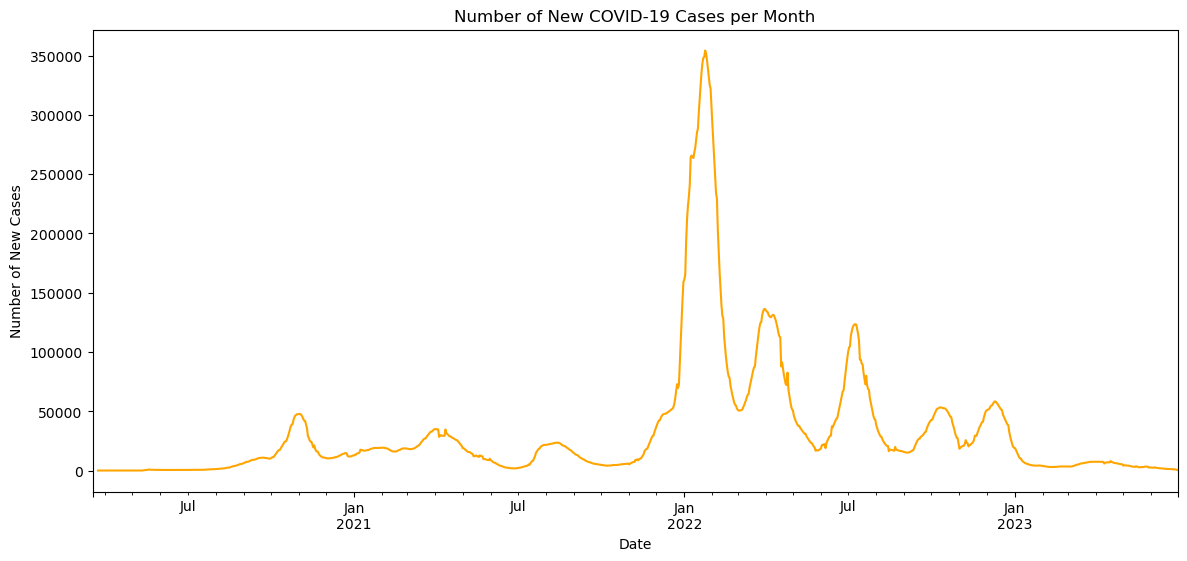

,Positifs,Positifs_smooth
Date,,
2020-03-18,0.0,NaN
2020-03-19,0.0,NaN
2020-03-20,0.0,NaN
2020-03-21,0.0,NaN
2020-03-22,0.0,NaN
...,...,...
2023-06-26,1568.0,1049.857143
2023-06-27,1035.0,980.571429
2023-06-28,0.0,800.285714


In [248]:
# Group by date and sum only the relevant column
pos = positives_raw.groupby("Date")["Positifs"].sum()

# Convert to DataFrame (optional, if you want a column instead of Series)
pos = pos.to_frame()

pos.index = pd.to_datetime(pos.index, format="%Y-%m-%d")
pos = pos.sort_index()

pos["Positifs_smooth"] = pos["Positifs"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 6)) 

pos["Positifs_smooth"].plot(ax=ax, legend=False, color="orange")

ax.set_title("Number of New COVID-19 Cases per Month")
ax.set_xlabel("Date")
ax.set_ylabel("Number of New Cases")

plt.xticks(rotation=0)

plt.show()

pos

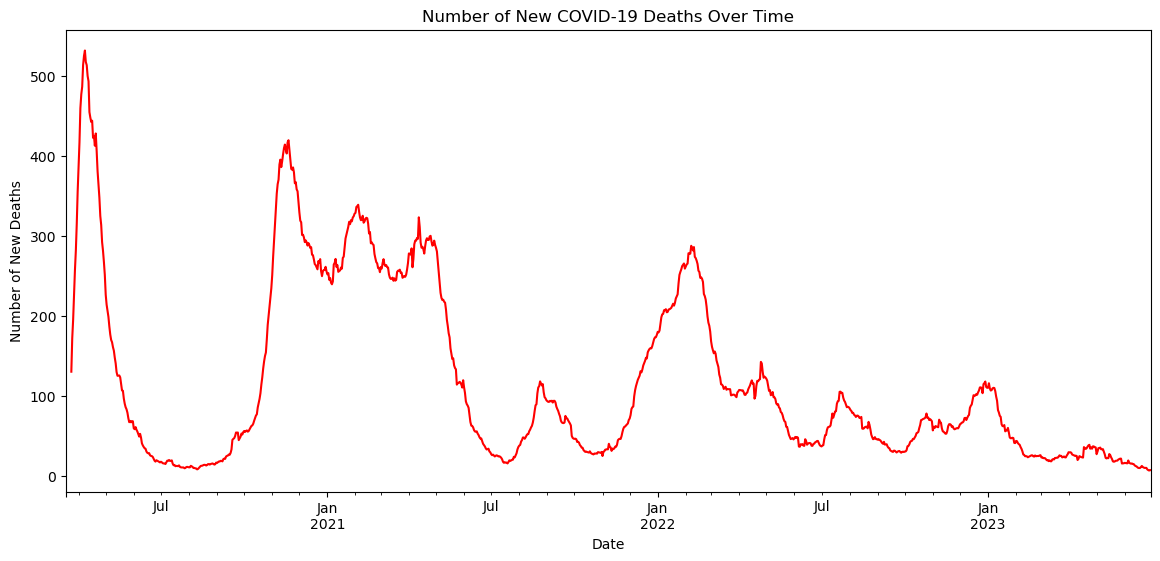

,Incidence décès hospitaliers,deaths_smooth
Date,,
2020-03-18,0.0,NaN
2020-03-19,155.0,NaN
2020-03-20,83.0,NaN
2020-03-21,115.0,NaN
2020-03-22,124.0,NaN
...,...,...
2023-06-26,13.0,7.857143
2023-06-27,10.0,7.000000
2023-06-28,4.0,6.428571


In [249]:
# Group by date and sum only the relevant column
deaths = positives_raw.groupby("Date")["Incidence décès hospitaliers"].sum()

# Convert to DataFrame (optional, if you want a column instead of Series)
deaths = deaths.to_frame()

deaths.index = pd.to_datetime(deaths.index, format="%Y-%m-%d")
deaths = deaths.sort_index()

deaths["deaths_smooth"] = deaths["Incidence décès hospitaliers"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 6)) 

deaths["deaths_smooth"].plot(ax=ax, legend=False, color="red")

ax.set_title("Number of New COVID-19 Deaths Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Number of New Deaths")

plt.xticks(rotation=0)

plt.show()

deaths


In [250]:
vac_rates = pd.read_csv("Data/vacsi-s-a-fra-2023-07-13-15h51.csv")

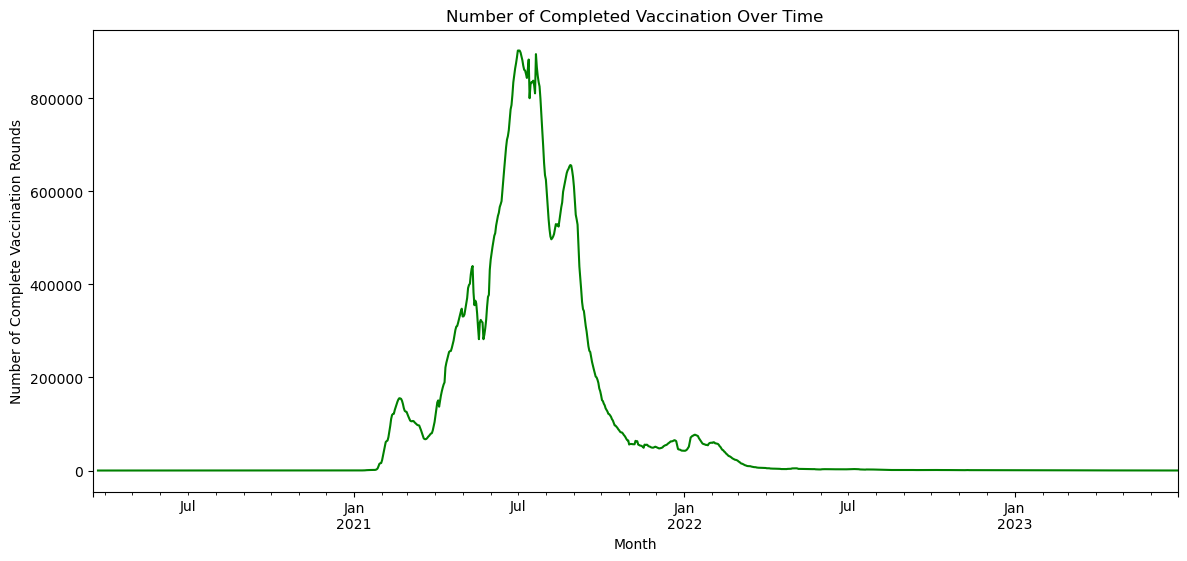

,n_complet_e,smooth
jour,,
2020-03-18,0,NaN
2020-03-19,0,NaN
2020-03-20,0,NaN
2020-03-21,0,NaN
2020-03-22,0,NaN
...,...,...
2023-06-26,78,78.571429
2023-06-27,92,76.000000
2023-06-28,90,72.000000


In [251]:
dose_1 = vac_rates[["jour", "n_complet_e"]]

dose_1 = dose_1.groupby("jour")["n_complet_e"].sum()
dose_1 = dose_1.to_frame()

dose_1.index = pd.to_datetime(dose_1.index, format="%Y-%m-%d")

dose_1 = dose_1.sort_index()

# 👉 Create full date range
full_range = pd.date_range(
    start="2020-03-18",
    end="2023-06-30",
    freq="D"
)

# 👉 Reindex and fill missing dates with 0
dose_1 = dose_1.reindex(full_range, fill_value=0)
dose_1.index.name = "jour"

dose_1["smooth"] = dose_1["n_complet_e"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 6))

dose_1["smooth"].plot(ax=ax, legend=False, color="green")

ax.set_title("Number of Completed Vaccination Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Complete Vaccination Rounds")

plt.xticks(rotation=0)

plt.show()

dose_1

In [252]:
total_deaths = positives_raw.groupby("Date")["Décès à l’hôpital"].sum()

total_deaths.index = pd.to_datetime(total_deaths.index, format="%Y-%m-%d")


Text(0, 0.5, 'Number of Incidences')

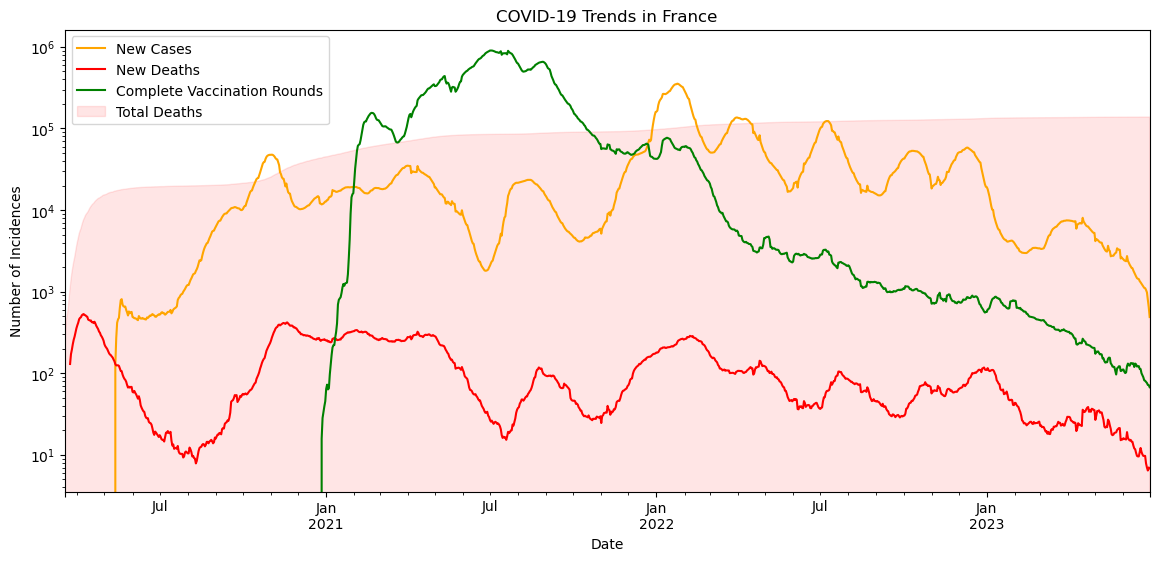

In [253]:
collected = pos.join(deaths).join(dose_1).join(total_deaths)

fig, ax = plt.subplots(figsize=(14, 6))

pos["Positifs_smooth"].plot(ax=ax, color="orange", label="New Cases")
deaths["deaths_smooth"].plot(ax=ax, color="red", label="New Deaths")
dose_1["smooth"].plot(ax=ax, color="green", label="Complete Vaccination Rounds")

ax.fill_between(
    total_deaths.index,
    total_deaths,
    color="red",
    alpha=0.1,
    label="Total Deaths"
)


plt.legend()

plt.yscale("log")

ax.set_title("COVID-19 Trends in France")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Incidences")



In [254]:
dep_raw = pd.read_csv("Data/table-indicateurs-open-data-dep-2023-06-30-17h59.csv")

incid = dep_raw.groupby("lib_dep")["tx_incid"].mean()

incid = incid.to_frame()

incid.to_csv("Data/cleaned_france.csv")


C:\Users\danny\AppData\Local\Temp\ipykernel_45508\3205595957.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  dep_raw = pd.read_csv("Data/table-indicateurs-open-data-dep-2023-06-30-17h59.csv")


In [258]:
totals_raw = pd.read_csv("Data/table-indicateurs-open-data-france-2023-06-30-17h59.csv")

In [263]:
totals = totals_raw[["incid_hosp", "incid_rad", "incid_dchosp"]].sum()

sankey_df = pd.DataFrame({
    "category": ["Recovered", "Deaths", "Unknown"],
    "value": [totals["incid_rad"], totals["incid_dchosp"], totals["incid_hosp"] - (totals["incid_rad"] + totals["incid_dchosp"])]
})

sankey_df

,category,value
0,Recovered,907351.0
1,Deaths,139592.0
2,Unknown,27449.0
